In [1]:
import os,sys,glob,copy
from datetime import datetime
from matplotlib import gridspec
import numpy as np
import pickle
#import itertools

# matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, AutoMinorLocator

# scipy
#import scipy.signal
import scipy.constants as sconst
from scipy.optimize import curve_fit
from scipy import stats

# astropy
from astropy.io import fits
from astropy.table import Table
from astropy.wcs import WCS, utils
import astropy.units as u
from astropy import constants as aconst
from astropy.io.ascii import SExtractor
from astropy.convolution import Gaussian2DKernel, convolve
from astropy.coordinates import SkyCoord, Angle
#from astropy.cosmology import Planck18, z_at_value, FlatLambdaCDM
from astropy.io.ascii import SExtractor

#from astroquery.atomic import AtomicLineList

# Photoutils
from photutils.detection import DAOStarFinder
from photutils.aperture import aperture_photometry,CircularAperture

# regions
from regions import PixCoord, CircleSkyRegion, EllipseSkyRegion, EllipsePixelRegion, TextSkyRegion

# reproject
from reproject import reproject_interp

## lmfit
import lmfit
from lmfit import Model

# Miscellaneous
from tqdm import tqdm_notebook as tqdm
import random

# JWST Grism analysis
from astropy.nddata import Cutout2D
from astropy.visualization import simple_norm
import grismconf
from jwst import datamodels
import jwst
from eiger_dk.get_rectified_2d_spectrum import get_rectified_2d_spectrum

import eiger_dk.jwst_nircam_grism as mygrism
import eiger_dk.grism_analysis as grism_analysis
import importlib
importlib.reload(mygrism)
importlib.reload(grism_analysis)

# 
from mypyplot import imshow_ptiles
# eiger_analysis
import eiger_analysis as eiger
importlib.reload(eiger)

## Wavelengths
w_lines = mygrism.wavelengths()

plt.rcParams["figure.figsize"] = (15,10)
plt.rcParams["font.size"] = 15
plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'

#import openpyxl

/scratch/kashinod/anaconda3/envs/jwst-1.6.2b/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.1
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


# Source list

In [2]:
src_id, src_ra, src_dec = np.loadtxt('list_src.txt', unpack=True, comments='#')
src_id = np.int32(src_id)
print(src_ra)
src_sky = SkyCoord(ra=src_ra, dec=src_dec, unit='deg')
src_sky
print(src_sky.size)
src_list = []

[15.05426945 15.0499309  15.0510412  15.0532788  15.0529152  15.0530851
 15.0547265  15.0257732  15.0293535 ]
9


In [9]:
wfss_rate_dir = '../calibrated_det1_wfss_hdr_corr_globalMedSubt/'
wfss_rate_dir = '../calibrated_img2_wfss_globalskySubtV4_emlineMasked_globalMedSubt/'
wfss_rate_dir = '../calibrated_img2_wfss_globalskySubtV4_emlineMasked_globalMedSubt_contSubt_kx51_9_Skx21_5/'
use_cal_instead_of_rate=True

wfss_cal_dir = '../calibrated_img2_wfss_globalskySubtV4_emlineMasked_globalMedSubt_contSubt_kx51_9_Skx21_5/'
#wfss_cal_fil_list = sorted(glob.glob(wfss_cal_dir+'jw0124300100[1,2,3,4]_0[2,4]101_000??_nrc?long_cal_globalMedSubt.fits'))

# wfss_cal_fil_list_a = sorted(glob.glob(wfss_cal_dir+'jw0124300100[1,2]_0[2,4]101_000??_nrcalong_cal_globalMedSubt.fits'))
# wfss_cal_fil_list_b = sorted(glob.glob(wfss_cal_dir+'jw0124300100[3,4]_0[2,4]101_000??_nrcblong_cal_globalMedSubt.fits'))

wfss_cal_fil_list_a = sorted(glob.glob(wfss_cal_dir+'jw0124300100[1,2]_0[2,4]101_000??_nrcalong_cal_globalMedSubt_emline.fits'))
wfss_cal_fil_list_b = sorted(glob.glob(wfss_cal_dir+'jw0124300100[3,4]_0[2,4]101_000??_nrcblong_cal_globalMedSubt_emline.fits'))

wfss_cal_fil_list = np.append(wfss_cal_fil_list_a,wfss_cal_fil_list_b)

print(len(wfss_cal_fil_list))
print(wfss_cal_fil_list)

photmjsr={'A':0.381, 'B':0.372}


96
['../calibrated_img2_wfss_globalskySubtV4_emlineMasked_globalMedSubt_contSubt_kx51_9_Skx21_5/jw01243001001_02101_00001_nrcalong_cal_globalMedSubt_emline.fits'
 '../calibrated_img2_wfss_globalskySubtV4_emlineMasked_globalMedSubt_contSubt_kx51_9_Skx21_5/jw01243001001_02101_00002_nrcalong_cal_globalMedSubt_emline.fits'
 '../calibrated_img2_wfss_globalskySubtV4_emlineMasked_globalMedSubt_contSubt_kx51_9_Skx21_5/jw01243001001_02101_00003_nrcalong_cal_globalMedSubt_emline.fits'
 '../calibrated_img2_wfss_globalskySubtV4_emlineMasked_globalMedSubt_contSubt_kx51_9_Skx21_5/jw01243001001_02101_00004_nrcalong_cal_globalMedSubt_emline.fits'
 '../calibrated_img2_wfss_globalskySubtV4_emlineMasked_globalMedSubt_contSubt_kx51_9_Skx21_5/jw01243001001_02101_00005_nrcalong_cal_globalMedSubt_emline.fits'
 '../calibrated_img2_wfss_globalskySubtV4_emlineMasked_globalMedSubt_contSubt_kx51_9_Skx21_5/jw01243001001_02101_00006_nrcalong_cal_globalMedSubt_emline.fits'
 '../calibrated_img2_wfss_globalskySubtV4_e

In [10]:
dwav = 0.000975
waxis_lin = 3.00 + dwav * np.arange(1240)
waxis_lin[0],waxis_lin[-1]

(3.0, 4.208025)

In [11]:
i_src = 0
ra0  = src_sky[i_src].ra.degree
dec0 = src_sky[i_src].dec.degree

frame_list = []
spec2d_flx_list = []
spec2d_var_list = []

for i_frame in range(len(wfss_cal_fil_list)):

    wfss_cal_fil = wfss_cal_fil_list[i_frame]
    basename = os.path.basename(wfss_cal_fil)
    print('=======================================')
    print(basename)
    
    #wfss_rate_fil = wfss_rate_dir+basename.replace('_cal','_rate')
    #hdul_wfss_rate = fits.open(wfss_rate_fil)
    
    hdul_wfss_cal = fits.open(wfss_cal_fil)
    wfss_cal_wcs = WCS(hdul_wfss_cal[1].header)
    wfss_cal_datamodel = datamodels.open(wfss_cal_fil)

    hdul_wfss_rate = copy.deepcopy(hdul_wfss_cal)
    
    #--------------------------------------
    try:
        use_wcs=False
        d, e, q, l, c, m, w, y, C, filt, grism, module = eiger.myextract(ra0, dec0, 
                                                                         hdul_wfss_rate, 
                                                                         wfss_cal_datamodel, 
                                                                         yoffset=0.0, 
                                                                         yhsize=50,
                                                                         use_wcs=use_wcs, 
                                                                         wcs=wfss_cal_wcs)
        
        #s = C.SENS['+1'].f(l)
        sens = grism_analysis.get_grism_sensitivity(filt, grism, module)
        s = np.interp(l, sens['WAVELENGTH'], sens['SENSITIVITY'])
        s[s==0]=np.nan
        
        ## MJy/sr --> DN/s --> erg/s/cm2
        if use_cal_instead_of_rate:
            d_s = d/photmjsr[module]/s
            e_s = e/photmjsr[module]/s
        else:
            d_s = d/s
            e_s = e/s

        shifted,shifted_var,shifted_lamb=eiger.shift_columns(y,d,e**2,l,q,ysize=101)
        scrunched,scrunched_var,scrunched_lamb=eiger.scrunch_columns(waxis_lin,
                                                                     shifted_lamb,
                                                                     shifted,
                                                                     shifted_var,
                                                                     module)

        shifted_s,shifted_var_s,shifted_lamb=eiger.shift_columns(y,d_s,e_s**2,l,q,ysize=101)
        scrunched_s,scrunched_var_s,scrunched_lamb=eiger.scrunch_columns(waxis_lin,
                                                                         shifted_lamb,
                                                                         shifted_s,
                                                                         shifted_var_s,
                                                                         module,
                                                                         flambda=True)
        
    except:
        print('Spectrum is out of field')
        continue

    print('Append this spectrum: ', basename)
    frame_list.append(basename)
    
    spec2d_flx_list.append(scrunched_s)
    spec2d_var_list.append(scrunched_var_s)
    


jw01243001001_02101_00001_nrcalong_cal_globalMedSubt_emline.fits


Set DATE-AVG to '2022-08-22T12:00:39.329' from MJD-AVG.
Set DATE-END to '2022-08-22T12:03:47.222' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -24.488497 from OBSGEO-[XYZ].
Set OBSGEO-H to 1574742494.802 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


Filter: F356W
grism: R
Module: A


2022-09-04 07:55:21,997 - stpipe - WARNING - /scratch/kashinod/anaconda3/envs/jwst-1.6.2b/lib/python3.9/site-packages/astropy/wcs/wcs.py:713: FITSFixedWarning: 'datfix' made the change 'Set DATE-BEG to '2022-08-22T12:05:23.818' from MJD-BEG.
Set DATE-AVG to '2022-08-22T12:08:31.712' from MJD-AVG.
Set DATE-END to '2022-08-22T12:11:39.605' from MJD-END'.
  warnings.warn(

2022-09-04 07:55:21,998 - stpipe - WARNING - /scratch/kashinod/anaconda3/envs/jwst-1.6.2b/lib/python3.9/site-packages/astropy/wcs/wcs.py:713: FITSFixedWarning: 'obsfix' made the change 'Set OBSGEO-L to   -55.649412 from OBSGEO-[XYZ].
Set OBSGEO-B to   -24.484976 from OBSGEO-[XYZ].
Set OBSGEO-H to 1574694722.201 from OBSGEO-[XYZ]'.
  warnings.warn(



Append this spectrum:  jw01243001001_02101_00001_nrcalong_cal_globalMedSubt_emline.fits
jw01243001001_02101_00002_nrcalong_cal_globalMedSubt_emline.fits
Filter: F356W
grism: R
Module: A


...

Append this spectrum:  jw01243001004_04101_00009_nrcblong_cal_globalMedSubt_emline.fits
jw01243001004_04101_00010_nrcblong_cal_globalMedSubt_emline.fits
Filter: F356W
grism: R
Module: B


2022-09-04 07:56:47,870 - stpipe - WARNING - /scratch/kashinod/anaconda3/envs/jwst-1.6.2b/lib/python3.9/site-packages/astropy/wcs/wcs.py:713: FITSFixedWarning: 'datfix' made the change 'Set DATE-BEG to '2022-08-22T18:44:30.931' from MJD-BEG.
Set DATE-AVG to '2022-08-22T18:47:38.825' from MJD-AVG.
Set DATE-END to '2022-08-22T18:50:46.718' from MJD-END'.
  warnings.warn(

2022-09-04 07:56:47,871 - stpipe - WARNING - /scratch/kashinod/anaconda3/envs/jwst-1.6.2b/lib/python3.9/site-packages/astropy/wcs/wcs.py:713: FITSFixedWarning: 'obsfix' made the change 'Set OBSGEO-L to   -55.460959 from OBSGEO-[XYZ].
Set OBSGEO-B to   -24.308711 from OBSGEO-[XYZ].
Set OBSGEO-H to 1572310980.699 from OBSGEO-[XYZ]'.
  warnings.warn(



Append this spectrum:  jw01243001004_04101_00010_nrcblong_cal_globalMedSubt_emline.fits
jw01243001004_04101_00011_nrcblong_cal_globalMedSubt_emline.fits
Filter: F356W
grism: R
Module: B


2022-09-04 07:56:48,878 - stpipe - WARNING - /scratch/kashinod/anaconda3/envs/jwst-1.6.2b/lib/python3.9/site-packages/astropy/wcs/wcs.py:713: FITSFixedWarning: 'datfix' made the change 'Set DATE-BEG to '2022-08-22T18:52:01.874' from MJD-BEG.
Set DATE-AVG to '2022-08-22T18:55:09.768' from MJD-AVG.
Set DATE-END to '2022-08-22T18:58:17.661' from MJD-END'.
  warnings.warn(

2022-09-04 07:56:48,879 - stpipe - WARNING - /scratch/kashinod/anaconda3/envs/jwst-1.6.2b/lib/python3.9/site-packages/astropy/wcs/wcs.py:713: FITSFixedWarning: 'obsfix' made the change 'Set OBSGEO-L to   -55.457166 from OBSGEO-[XYZ].
Set OBSGEO-B to   -24.305163 from OBSGEO-[XYZ].
Set OBSGEO-H to 1572263166.076 from OBSGEO-[XYZ]'.
  warnings.warn(



Append this spectrum:  jw01243001004_04101_00011_nrcblong_cal_globalMedSubt_emline.fits
jw01243001004_04101_00012_nrcblong_cal_globalMedSubt_emline.fits
Filter: F356W
grism: R
Module: B
Append this spectrum:  jw01243001004_04101_00012_nrcblong_cal_globalMedSubt_emline.fits


In [22]:
sens2.shape

(104, 1243)

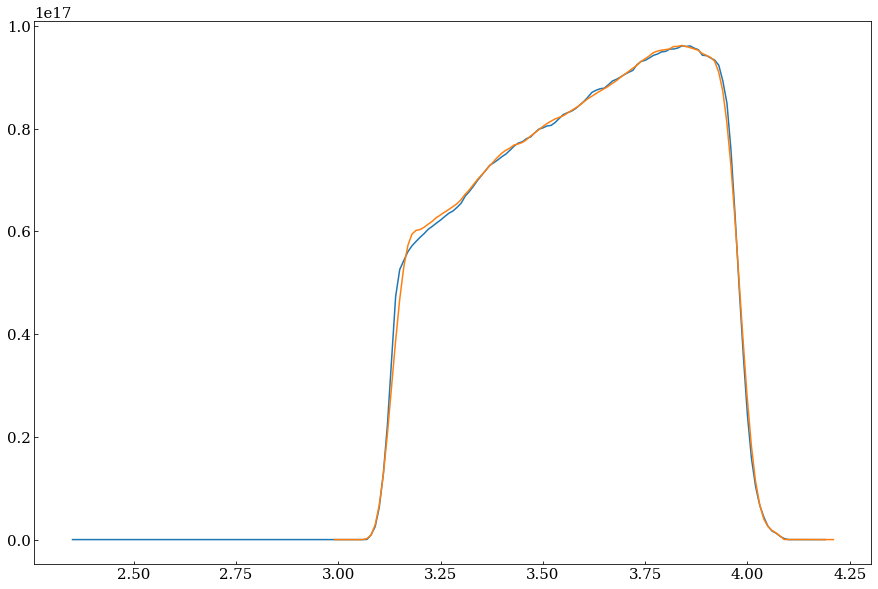

In [24]:
plt.plot(sens['WAVELENGTH'], sens['SENSITIVITY'])
sens2 = C.SENS['+1'].f(l)
plt.plot(l[0,:], sens2[0,:])


In [12]:
idx_1a = [i for i in range(len(frame_list)) if 'nrcalong' in frame_list[i] and 'jw01243001001' in frame_list[i]]
idx_1b = [i for i in range(len(frame_list)) if 'nrcblong' in frame_list[i] and 'jw01243001001' in frame_list[i]]
idx_2a = [i for i in range(len(frame_list)) if 'nrcalong' in frame_list[i] and 'jw01243001002' in frame_list[i]]
idx_2b = [i for i in range(len(frame_list)) if 'nrcblong' in frame_list[i] and 'jw01243001002' in frame_list[i]]
idx_3a = [i for i in range(len(frame_list)) if 'nrcalong' in frame_list[i] and 'jw01243001003' in frame_list[i]]
idx_3b = [i for i in range(len(frame_list)) if 'nrcblong' in frame_list[i] and 'jw01243001003' in frame_list[i]]
idx_4a = [i for i in range(len(frame_list)) if 'nrcalong' in frame_list[i] and 'jw01243001004' in frame_list[i]]
idx_4b = [i for i in range(len(frame_list)) if 'nrcblong' in frame_list[i] and 'jw01243001004' in frame_list[i]]

print('len(idx_1a): ', len(idx_1a))
print('len(idx_1b): ', len(idx_1b))
print('len(idx_2a): ', len(idx_2a))
print('len(idx_2b): ', len(idx_2b))
print('len(idx_3a): ', len(idx_3a))
print('len(idx_3b): ', len(idx_3b))
print('len(idx_4a): ', len(idx_4a))
print('len(idx_4b): ', len(idx_4b))


len(idx_1a):  24
len(idx_1b):  0
len(idx_2a):  24
len(idx_2b):  0
len(idx_3a):  0
len(idx_3b):  24
len(idx_4a):  0
len(idx_4b):  24


In [13]:
spec2d_flx_arr = np.array(spec2d_flx_list)
spec2d_var_arr = np.array(spec2d_var_list)
spec2d_flx_comb1a = np.nanmedian(spec2d_flx_arr[idx_1a,:,:], axis=0)
spec2d_flx_comb2a = np.nanmedian(spec2d_flx_arr[idx_2a,:,:], axis=0)
spec2d_flx_comb3b = np.nanmedian(spec2d_flx_arr[idx_3b,:,:], axis=0)
spec2d_flx_comb4b = np.nanmedian(spec2d_flx_arr[idx_3b,:,:], axis=0)

from median_filters import median_filter2d
spec2d_flx_comb1a_contSubt = spec2d_flx_comb1a - median_filter2d(spec2d_flx_comb1a, 51, 1, 9)
spec2d_flx_comb2a_contSubt = spec2d_flx_comb2a - median_filter2d(spec2d_flx_comb2a, 51, 1, 9)
spec2d_flx_comb3b_contSubt = spec2d_flx_comb3b - median_filter2d(spec2d_flx_comb3b, 51, 1, 9)
spec2d_flx_comb4b_contSubt = spec2d_flx_comb4b - median_filter2d(spec2d_flx_comb4b, 51, 1, 9)

2022-09-04 07:58:37,427 - stpipe - WARNING - /scratch/kashinod/anaconda3/envs/jwst-1.6.2b/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  r, k = function_base._ureduce(a, func=_nanmedian, axis=axis, out=out,



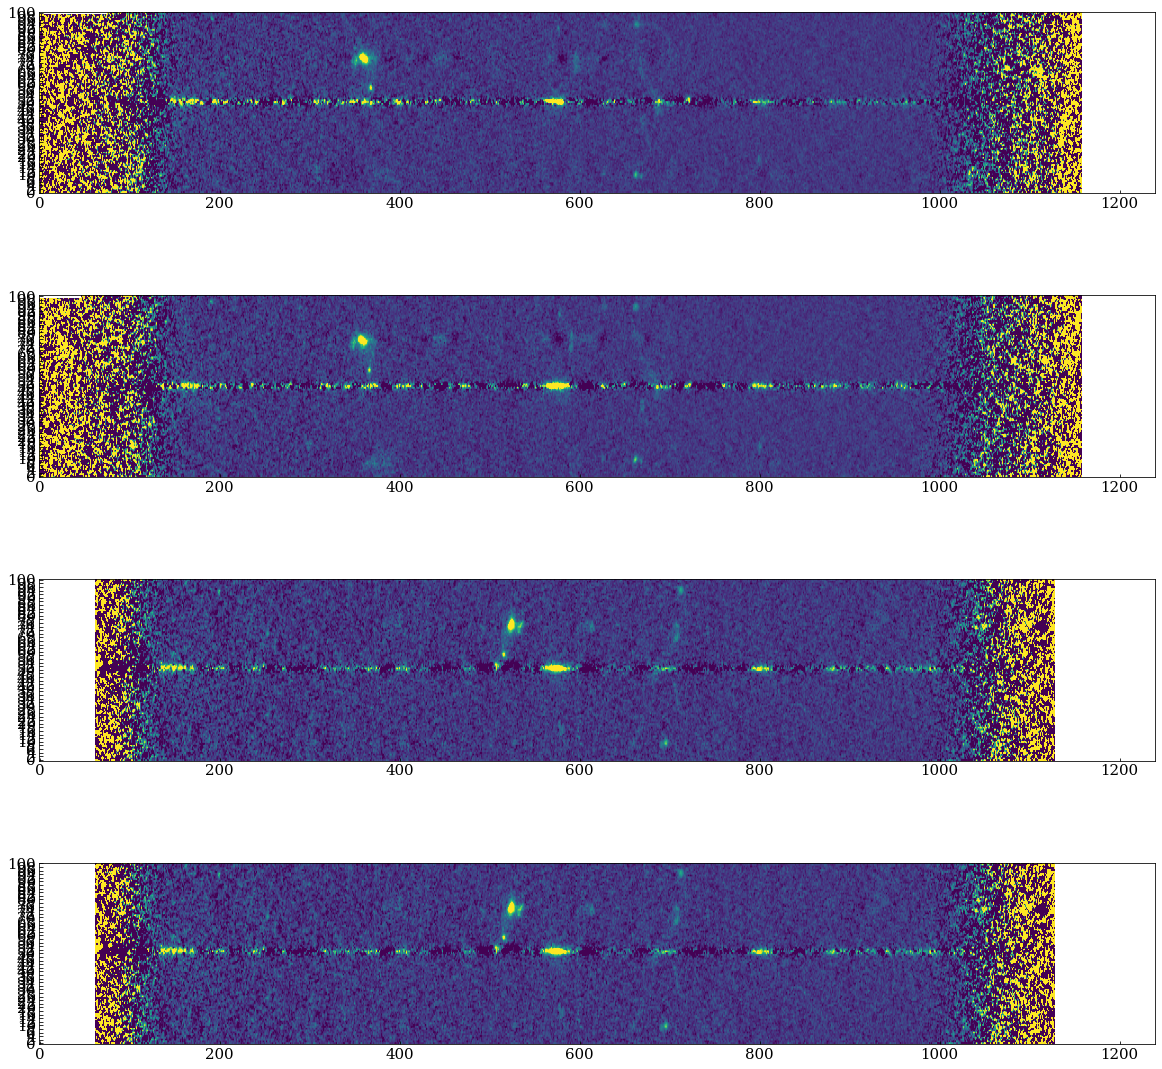

In [14]:
fig = plt.figure(figsize=(20,20))
ax = fig.subplots(nrows=4, ncols=1)
vmin = -1e-20
vmax = 5e-20
ax[0].imshow(spec2d_flx_comb1a, vmin=vmin, vmax=vmax, aspect=2, origin='lower')
ax[1].imshow(spec2d_flx_comb2a, vmin=vmin, vmax=vmax, aspect=2, origin='lower')
ax[2].imshow(spec2d_flx_comb3b, vmin=vmin, vmax=vmax, aspect=2, origin='lower')
ax[3].imshow(spec2d_flx_comb4b, vmin=vmin, vmax=vmax, aspect=2, origin='lower')
for a in ax:
    a.yaxis.set_major_locator(MultipleLocator(2))
    #a.grid()

In [15]:
importlib.reload(grism_analysis)

idx_aa = np.append(idx_1a,idx_2a)
idx_bb = np.append(idx_3b,idx_4b)

sci_a  = np.nanmedian(spec2d_flx_arr[idx_aa, :,:], axis=0)
sci_b  = np.nanmedian(spec2d_flx_arr[idx_bb, :,:], axis=0)
sci_1a = np.nanmedian(spec2d_flx_arr[idx_1a, :,:], axis=0)
sci_2a = np.nanmedian(spec2d_flx_arr[idx_2a, :,:], axis=0)
sci_3b = np.nanmedian(spec2d_flx_arr[idx_3b, :,:], axis=0)
sci_4b = np.nanmedian(spec2d_flx_arr[idx_4b, :,:], axis=0)

img_list = [sci_a, sci_b, sci_1a, sci_2a, sci_3b, sci_4b]

extname_list = ['SCI_A','SCI_B','SCI_1A','SCI_2A','SCI_3B','SCI_4B']

unit_list = np.repeat('erg/s/cm2/Angstrom', len(img_list))

fil = 'spec2dCoadded_emline_id'+str(src_id[i_src]).zfill(10)+'_'+\
'{:.6f}'.format(ra0)+'_'+'{:.6f}'.format(dec0)+'_20220903.fits'
print('Save ', fil)
grism_analysis.save_spec2d_fits(fil, img_list, waxis_lin * u.um, 
                                extname_list, unit_list, overwrite=True)



Save  spec2dCoadded_emline_id0009999999_15.054269_28.040498_20220903.fits


In [16]:
importlib.reload(grism_analysis)

extname_list = []
img_list = []
for vis in [1,2,3,4]:
    for gr in [2,4]:
        for pt in range(1,13):
            for module in ['a','b']:
                fname = 'jw0124300100'+str(vis)+'_0'+str(gr)+'101_'+str(pt).zfill(5)+'_nrc'+module+'long_cal_globalMedSubt.fits'
                tmp = np.where(np.array(frame_list) == fname)[0]
                #print(fname, tmp.size)
                if tmp.size==1:
                    extname_list.append('SCI_'+str(vis)+module.upper()+str(12*int(gr/2-1)+pt).zfill(2))
                    img_list.append(spec2d_flx_arr[tmp[0],:,:])
                    
unit_list = np.repeat('erg/s/cm2/Angstrom', len(img_list))

fil = 'spec2d_individual_emline_SCI_id'+str(src_id[i_src]).zfill(10)+'_'+\
'{:.6f}'.format(ra0)+'_'+'{:.6f}'.format(dec0)+'_20220903.fits'
print('Save ', fil)
grism_analysis.save_spec2d_fits(fil, img_list, waxis_lin * u.um, 
                                extname_list, unit_list, overwrite=True)



Save  spec2d_individual_emline_SCI_id0009999999_15.054269_28.040498_20220903.fits


In [17]:
importlib.reload(grism_analysis)

extname_list = []
img_list = []
for vis in [1,2,3,4]:
    for gr in [2,4]:
        for pt in range(1,13):
            for module in ['a','b']:
                fname = 'jw0124300100'+str(vis)+'_0'+str(gr)+'101_'+str(pt).zfill(5)+'_nrc'+module+'long_cal_globalMedSubt.fits'
                tmp = np.where(np.array(frame_list) == fname)[0]
                #print(fname, tmp.size)
                if tmp.size==1:
                    extname_list.append('VAR_'+str(vis)+module.upper()+str(12*int(gr/2-1)+pt).zfill(2))
                    img_list.append(spec2d_var_arr[tmp[0],:,:])
                    
unit_list = np.repeat('erg/s/cm2/Angstrom', len(img_list))

fil = 'spec2d_individual_emline_VAR_id'+str(src_id[i_src]).zfill(10)+'_'+\
'{:.6f}'.format(ra0)+'_'+'{:.6f}'.format(dec0)+'_20220903.fits'
print('Save ', fil)
grism_analysis.save_spec2d_fits(fil, img_list, waxis_lin * u.um, 
                                extname_list, unit_list, overwrite=True)



Save  spec2d_individual_emline_VAR_id0009999999_15.054269_28.040498_20220903.fits


In [ ]:
stop

In [ ]:
def save_spec2d_fits(filname,
                     list_of_images, 
                     waxis,
                     extname_list,
                     unit_list,
                     overwrite=False):
    hdu = fits.PrimaryHDU()
    hdul = [hdu]
    
    for i in range(len(list_of_images)):
        print(i)
        hdr = fits.Header()
        hdr['EXTNAME']=extname_list[i]
        hdr['XTENSION']='IMAGE'
        hdr['BUNIT']=unit_list[i]
        hdr['NAXIS']=2
        hdr['NAXIS1']=list_of_images[i].shape[1]
        hdr['NAXIS2']=list_of_images[i].shape[0]
        hdr['CTYPE1']='WAVELENGTH'
        hdr['CUNIT1']='Angstrom'
        hdr['CRPIX1']=1.0
        hdr['CRVAL1']=waxis[0].to_value(u.angstrom)
        hdr['CDELT1']=(waxis[1]-waxis[0]).to_value(u.angstrom)
        hdu = fits.ImageHDU(list_of_images[i], header=hdr)
        hdul.append(hdu)
    hdul = fits.HDUList(hdul)
    hdul.writeto(filname, overwrite=overwrite)

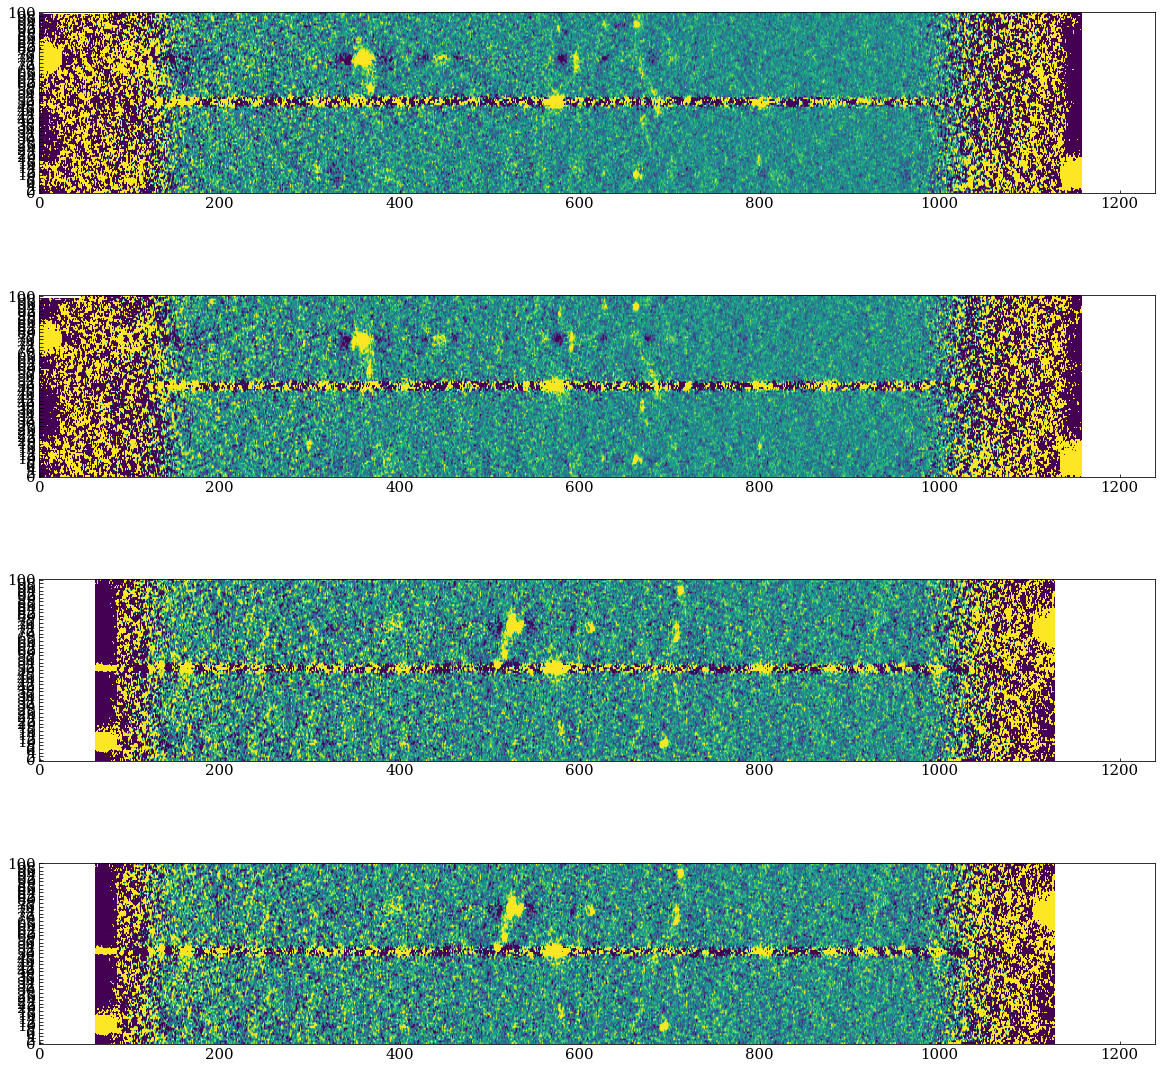

In [36]:
fig = plt.figure(figsize=(20,20))
ax = fig.subplots(nrows=4, ncols=1)
vmin = -1e-20
vmax = 1e-20
ax[0].imshow(spec2d_flx_comb1a_contSubt, vmin=vmin, vmax=vmax, aspect=2, origin='lower')
ax[1].imshow(spec2d_flx_comb2a_contSubt, vmin=vmin, vmax=vmax, aspect=2, origin='lower')
ax[2].imshow(spec2d_flx_comb3b_contSubt, vmin=vmin, vmax=vmax, aspect=2, origin='lower')
ax[3].imshow(spec2d_flx_comb4b_contSubt, vmin=vmin, vmax=vmax, aspect=2, origin='lower')
for a in ax:
    a.yaxis.set_major_locator(MultipleLocator(2))
    #a.grid()

2022-09-03 22:28:10,131 - stpipe - WARNING - /tmp/ipykernel_973164/4102567361.py:3: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  y0 = np.int(spec2d_flx_arr[0,:,:].shape[0]/2)

2022-09-03 22:28:10,159 - stpipe - WARNING - /scratch/kashinod/anaconda3/envs/jwst-1.6.2b/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  r, k = function_base._ureduce(a, func=_nanmedian, axis=axis, out=out,

2022-09-03 22:28:10,173 - stpipe - WARNING - /scratch/kashinod/anaconda3/envs/jwst-1.6.2b/lib/python3.9/site-p

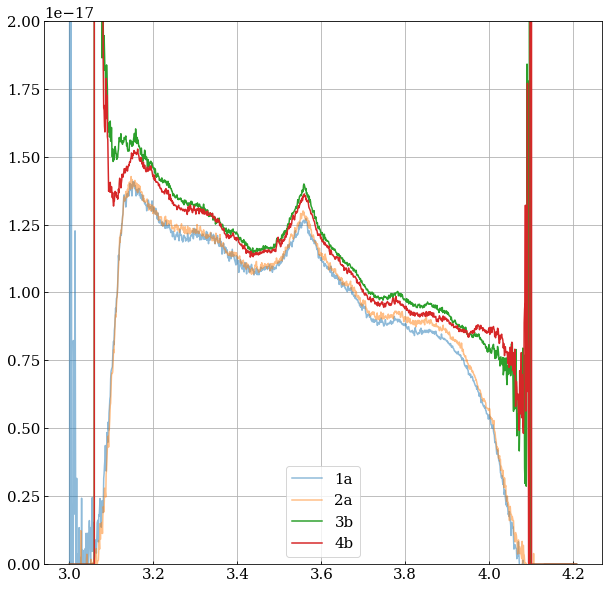

In [37]:
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot()
y0 = np.int(spec2d_flx_arr[0,:,:].shape[0]/2)

ax.plot(waxis_lin, np.nansum(np.nanmedian(spec2d_flx_arr[idx_visit1a,y0-3:y0+4,:], axis=0), axis=0), label='1a', alpha=0.5)
ax.plot(waxis_lin, np.nansum(np.nanmedian(spec2d_flx_arr[idx_visit2a,y0-3:y0+4,:], axis=0), axis=0), label='2a', alpha=0.5)
ax.plot(waxis_lin, np.nansum(np.nanmedian(spec2d_flx_arr[idx_visit3b,y0-3:y0+4,:], axis=0), axis=0), label='3b')
ax.plot(waxis_lin, np.nansum(np.nanmedian(spec2d_flx_arr[idx_visit4b,y0-3:y0+4,:], axis=0), axis=0), label='4b')
ax.set_ylim(0.9e-17,1.5e-17)
ax.set_ylim(0,2.0e-17)
#ax.set_xlim(3.4, 3.7)
ax.legend()
ax.grid()

In [ ]:
    
    s = C.SENS['+1'].f(l)
    s[s==0]=np.nan

d_s = d/s
e_s = e/s


shifted,shifted_var,shifted_lamb=shift_columns(y,d,e**2,l,q,ysize=31)


xtmp = np.arange(shifted.shape[0])-np.int(shifted.shape[0]/2.)
ytmp = np.nanmedian(shifted,axis=1)
p0  = np.array([np.max(ytmp[10:21]), yoffset_init, 0.3, 0.0, 0.0])
plo = np.array([p0[0]*0.5, yoffset_init-2.0, 0.0, -np.infty, -np.infty])
pup = np.array([p0[0]*1.5, yoffset_init+2.0, 3.0, +np.infty, +np.infty])

idx_fit = np.arange(10,21)
popt, pcov = curve_fit(mygauss, xtmp[idx_fit], ytmp[idx_fit], p0=p0, bounds=(plo, pup))
print(popt)
yoffset_new = popt[1]
yoffset_result[i_pdit, i_src] = yoffset_new
print('yoffset_new: ', yoffset_new)



## imshow(shifted)
axl = fig.add_subplot(gs[1+2*i_pdit+1,0])
axl.imshow(shifted, origin='lower', vmin=0, vmax=popt[0], aspect=5)
axl.axhline(15+popt[1])
axl.text(30, 28, 'yoffset_new={:.4f}'.format(yoffset_new), color='red', va='top')
## plot gaussian fit
axr = fig.add_subplot(gs[1+2*i_pdit+1,1])
axr.plot(xtmp, ytmp)
axr.plot(xtmp, mygauss(xtmp,*popt))
axr.axvline(popt[1])
axr.text(axr.get_xlim()[0], axr.get_ylim()[1]*0.8, ' $\sigma_y$={:.4f}'.format(popt[2]))

### extract with new yoffset
d, e, q, l, c, m, w, y, C = myextract(ra0, dec0, hdul_rate, wfss_cal_datamodel, yoffset=yoffset_new, use_wcs=use_wcs, wcs=WCS(hdul_cal[1].header))
s = C.SENS['+1'].f(l)
s[s==0]=np.nan

d_s = d/s
e_s = e/s

shifted,shifted_var,shifted_lamb=shift_columns(y,d,e**2,l,q,ysize=31)
#     xtmp = np.arange(shifted.shape[0])-np.int(shifted.shape[0]/2.)
#     ytmp = np.nanmedian(shifted,axis=1)
#     plt.plot(xtmp, ytmp)
#     p0 = [np.max(ytmp[10:21]), 0., 2.0, 0.0, 0.0]
#     popt, pcov = curve_fit(mygauss, xtmp, ytmp, p0=p0)
#     print(popt)


scrunched,scrunched_var,scrunched_lamb=scrunch_columns(waxis_lin,shifted_lamb,shifted,shifted_var,module)

shifted_s,shifted_var_s,shifted_lamb=shift_columns(y,d_s,e_s**2,l,q,ysize=31)
scrunched_s,scrunched_var_s,scrunched_lamb=scrunch_columns(waxis_lin,shifted_lamb,shifted_s,shifted_var_s,module,flambda=True)





In [ ]:

yoffset_result = np.zeros((4, len(src_sky))) + np.nan

#spec2d_list = []
#for i in range(len(src_sky)):
for i in [-2]:
    i_src = i
    
    plt.clf()
    plt.close()
    fig = plt.figure(figsize=(30,40))
    gs = gridspec.GridSpec(ncols=2, nrows=9, width_ratios=[5, 1])
    
    res = {'src_id':src_id[i_src],
           'sky_coord': src_sky[i_src],
           'yoffset': np.zeros(4)+np.nan,
           'ysigma':np.zeros(4)+np.nan,
           'wavelength': waxis_lin,
           'sensitivity': waxis_lin*np.nan,
           'scrunched': np.zeros((4,31, 1240))+np.nan,
           'scrunched_var': np.zeros((4,31, 1240))+np.nan,
           'flambda': np.zeros((4,31, 1240))+np.nan,
           'flambda_var': np.zeros((4,31, 1240))+np.nan}

    ax = fig.add_subplot(gs[0,0])
    ax.imshow(dirimg, vmin=0, vmax=1.0)
    ax.set_xlim(src_x[i_src]-100, src_x[i_src]+100)
    ax.set_ylim(src_y[i_src]-100, src_y[i_src]+100)
    
    for i_pdit in range(4):
    
        wfss_rate_fil = '../calibrated_spc2_bsub_rate_hdr_corr/jw01076101001_02101_'+str(i_pdit+1).zfill(5)+'_nrc'+module.lower()+'long_rate.fits'
        wfss_cal_fil = '../calibrated_img2_wfss/jw01076101001_02101_'+str(i_pdit+1).zfill(5)+'_nrc'+module.lower()+'long_cal.fits'
        hdul_rate = fits.open(wfss_rate_fil)
        hdul_cal = fits.open(wfss_cal_fil)
        hdul_cal = fits.open(wfss_cal_fil)
        wfss_cal_wcs = WCS(hdul_cal[1].header)
        wfss_cal_datamodel = datamodels.open(wfss_cal_fil)

        #--------------------------------------
        ra0  = src_sky[i_src].ra.degree
        dec0 = src_sky[i_src].dec.degree
        
        #try:
        if 1==1:
            use_wcs=True
            d, e, q, l, c, m, w, y, C = myextract(ra0, dec0, hdul_rate, wfss_cal_datamodel, yoffset=0.0, use_wcs=use_wcs, wcs=WCS(hdul_cal[1].header))
            
            ## imshow(shifted)
            ax = fig.add_subplot(gs[1+2*i_pdit,0:2])
            vmax = np.nanpercentile(d,95)
            ax.imshow(d, origin='lower', vmin=0, vmax=vmax, aspect=5)
            x_trace = np.arange(d.shape[1])
            y_trace = x_trace*0.
            for j in range(x_trace.size):
                y_trace[j] = np.interp(0., y[:,j], np.arange(d.shape[0]))
            ax.plot(x_trace, y_trace, color='red')
            ax.plot(x_trace, y_trace + yoffset_init, color='red', ls='dashed')
            
            
            s = C.SENS['+1'].f(l)
            s[s==0]=np.nan

            d_s = d/s
            e_s = e/s

            
            shifted,shifted_var,shifted_lamb=shift_columns(y,d,e**2,l,q,ysize=31)

            
            xtmp = np.arange(shifted.shape[0])-np.int(shifted.shape[0]/2.)
            ytmp = np.nanmedian(shifted,axis=1)
            p0  = np.array([np.max(ytmp[10:21]), yoffset_init, 0.3, 0.0, 0.0])
            plo = np.array([p0[0]*0.5, yoffset_init-2.0, 0.0, -np.infty, -np.infty])
            pup = np.array([p0[0]*1.5, yoffset_init+2.0, 3.0, +np.infty, +np.infty])

            idx_fit = np.arange(10,21)
            popt, pcov = curve_fit(mygauss, xtmp[idx_fit], ytmp[idx_fit], p0=p0, bounds=(plo, pup))
            print(popt)
            yoffset_new = popt[1]
            yoffset_result[i_pdit, i_src] = yoffset_new
            print('yoffset_new: ', yoffset_new)

            
            
            ## imshow(shifted)
            axl = fig.add_subplot(gs[1+2*i_pdit+1,0])
            axl.imshow(shifted, origin='lower', vmin=0, vmax=popt[0], aspect=5)
            axl.axhline(15+popt[1])
            axl.text(30, 28, 'yoffset_new={:.4f}'.format(yoffset_new), color='red', va='top')
            ## plot gaussian fit
            axr = fig.add_subplot(gs[1+2*i_pdit+1,1])
            axr.plot(xtmp, ytmp)
            axr.plot(xtmp, mygauss(xtmp,*popt))
            axr.axvline(popt[1])
            axr.text(axr.get_xlim()[0], axr.get_ylim()[1]*0.8, ' $\sigma_y$={:.4f}'.format(popt[2]))

            ### extract with new yoffset
            d, e, q, l, c, m, w, y, C = myextract(ra0, dec0, hdul_rate, wfss_cal_datamodel, yoffset=yoffset_new, use_wcs=use_wcs, wcs=WCS(hdul_cal[1].header))
            s = C.SENS['+1'].f(l)
            s[s==0]=np.nan

            d_s = d/s
            e_s = e/s

            shifted,shifted_var,shifted_lamb=shift_columns(y,d,e**2,l,q,ysize=31)
        #     xtmp = np.arange(shifted.shape[0])-np.int(shifted.shape[0]/2.)
        #     ytmp = np.nanmedian(shifted,axis=1)
        #     plt.plot(xtmp, ytmp)
        #     p0 = [np.max(ytmp[10:21]), 0., 2.0, 0.0, 0.0]
        #     popt, pcov = curve_fit(mygauss, xtmp, ytmp, p0=p0)
        #     print(popt)


            scrunched,scrunched_var,scrunched_lamb=scrunch_columns(waxis_lin,shifted_lamb,shifted,shifted_var,module)

            shifted_s,shifted_var_s,shifted_lamb=shift_columns(y,d_s,e_s**2,l,q,ysize=31)
            scrunched_s,scrunched_var_s,scrunched_lamb=scrunch_columns(waxis_lin,shifted_lamb,shifted_s,shifted_var_s,module,flambda=True)
            res['yoffset'][i_pdit] = yoffset_new
            res['ysigma'][i_pdit] = popt[2]
            res['sensitivity'] = C.SENS['+1'].f(waxis_lin) 
            res['scrunched'][i_pdit,:,:] = scrunched
            res['scrunched_var'][i_pdit,:,:] = scrunched_var
            res['flambda'][i_pdit,:,:] = scrunched_s
            res['flambda_var'][i_pdit,:,:] = scrunched_var_s

        #except:
            print('spectrum is out of field.')
            
        hdul_cal.close()
        hdul_rate.close()
                
    #spec2d_list.append(res)




 
    
    